### Data loading and set up

In [1]:
from pathlib import Path
from cortech import Cortex, Surface
import nibabel as nib
import pyvista as pv
import numpy as np
from nibabel.freesurfer import read_morph_data
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

# Base directories
subjects_dir = Path("/home/oana/UDel/fsruns")
mre_dir = Path("/home/oana/MRE_analysis") 
group_dir = Path("/home/oana/MRE_group_results")


# Fetch fsaverage
fsavg = Cortex.from_freesurfer_subject_dir("fsaverage", registration="sphere.reg")

# Read in the subjects and prepare
print("Reading in the data")
subids=["0001","0002","0003","0004","0005","0006","0007","0008","0009","0010","0011"]
cortices = {}
for sub in subids:
    subject = subjects_dir / sub
    mre_dir = Path("/home/oana/MRE_analysis") / sub
    cortices[sub] = Cortex.from_freesurfer_subject_dir(subject, pial="pial.T1", registration="sphere.reg")
    for hemi, hemi_fsav in zip(cortices[sub].hemispheres, fsavg.hemispheres):
        # Add spherical registration to fsav
        hemi.registration.project(hemi_fsav.registration)
        hemi.white.smooth_taubin(n_iter=5, inplace=True)
        hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# Fit the layers
print("Fitting the middle layer")
mid_layers_subjects = {}
for sub in subids:
    mid_layers_subjects[sub] = {
        "lh": cortices[sub].lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
        "rh": cortices[sub].rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
    }

# Okay, interpolate the data to the middle surface and then map to fsavg
scan_names = {
    "stiff":  "MRE_stiffness_in_T1_space.nii.gz",
    "real": "MRE_real_in_T1_space.nii.gz",
    "imag": "MRE_imag_in_T1_space.nii.gz",
    "myelin": "Myelin.nii.gz",
}

print("Interpolating data to fsaverage")
subject_data_on_fsaverage = {}
for sub in subids:
    cortex = cortices[sub]
    mid_layer = mid_layers_subjects[sub]
    fsavg_data = {}
    mre_dir = Path("/home/oana/MRE_analysis") / sub
    for scan in scan_names.keys():
        im_tmp = nib.load(mre_dir / f"{scan_names[scan]}")
        hemi_data = {}
        for hemi in cortex.hemispheres:
            # Interpolate
            hemi_data_tmp = mid_layer[hemi.name].interpolate_to_nodes(im_tmp.get_fdata(), im_tmp.affine)
            # Map
            hemi_data[hemi.name] = hemi.registration.resample(hemi_data_tmp)
        fsavg_data[scan] = hemi_data

    geometric = {
        "curvature": "curv",
        "thickness": "thickness",
        "sulcal_depth": "sulc",
    }

    for geom_name, fs_name in geometric.items():

        hemi_data = {}

        for hemi in cortex.hemispheres:

            surf_file = subjects_dir / sub / "surf" / f"{hemi.name}.{fs_name}"
            data = read_morph_data(surf_file)

            # Directly resample 
            hemi_data[hemi.name] = hemi.registration.resample(data)

        fsavg_data[geom_name] = hemi_data
    subject_data_on_fsaverage[sub] = fsavg_data


# Let's compute the average over subjects for each scan along with the standard deviation
average = {}
sd = {}

for scan in scan_names.keys():
    hemi_mean = {}
    hemi_sd = {}
    for hemi in ["lh", "rh"]:
        #data_tmp = np.zeros((fsavg.lh.white.n_vertices, len(subids)))
        n_vertices = subject_data_on_fsaverage[subids[0]][scan][hemi].shape[0]
        data_tmp = np.zeros((n_vertices, len(subids)))
        for s, sub in enumerate(subids):
            data_tmp[:, s] = subject_data_on_fsaverage[sub][scan][hemi]
        hemi_mean[hemi] = data_tmp.mean(axis=1)
        hemi_sd[hemi] = data_tmp.std(axis=1)
        # Save for later use
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_mean[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{scan}.mid.layer.average.mgh")
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_sd[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.fsaverage.{scan}.mid.layer.sd.mgh")
    average[scan] = hemi_mean
    sd[scan] = hemi_sd

geo_average = {}
geo_sd = {}

for geom in geometric.keys():
    hemi_mean = {}
    hemi_sd = {}

    for hemi in ["lh", "rh"]:
        n_vertices = subject_data_on_fsaverage[subids[0]][geom][hemi].shape[0]
        data_tmp = np.zeros((n_vertices, len(subids)))

        for s, sub in enumerate(subids):
            data_tmp[:, s] = subject_data_on_fsaverage[sub][geom][hemi]

        hemi_mean[hemi] = data_tmp.mean(axis=1)
        hemi_sd[hemi] = data_tmp.std(axis=1)
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_mean[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{geom}.mid.layer.average.mgh")

        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_sd[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{geom}.mid.layer.sd.mgh")

    geo_average[geom] = hemi_mean
    geo_sd[geom] = hemi_sd



Reading in the data
Fitting the middle layer
Interpolating data to fsaverage


### Vertex-wise correlations across 11 subjects

In [2]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import nibabel as nib
import numpy as np
from pathlib import Path

# Where correlation maps will be saved
corr_dir = Path("/home/oana/MRE_group_results/correlations")
corr_dir.mkdir(exist_ok=True)

# Parameters
mre_params = ["stiff", "real", "imag", "myelin"]
geo_params = ["curvature", "thickness", "sulcal_depth"]

vertexwise_results = {}

for hemi in ["lh", "rh"]:

    print(f"\nRunning vertex-wise stats for {hemi}")

    n_vertices = subject_data_on_fsaverage[subids[0]]["stiff"][hemi].shape[0]

    # Build matrices (subjects x vertices)
    matrices = {}
    for param in mre_params + geo_params:

        mat = np.zeros((len(subids), n_vertices))

        for s, sub in enumerate(subids):
            mat[s, :] = subject_data_on_fsaverage[sub][param][hemi]

        matrices[param] = mat

    vertexwise_results[hemi] = {}

    for p1 in mre_params:
        for p2 in geo_params:

            print(f"  {p1} vs {p2}")

            rho = np.zeros(n_vertices)
            pvals = np.zeros(n_vertices)

            for v in range(n_vertices):

                r, p = spearmanr(
                    matrices[p1][:, v],
                    matrices[p2][:, v]
                )

                rho[v] = r
                pvals[v] = p

            # FDR correction
            _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")

            rho_fdr = rho.copy()
            rho_fdr[pvals_fdr > 0.05] = 0

            pair_name = f"{p1}_vs_{p2}"

            vertexwise_results[hemi][pair_name] = {
                "rho": rho,
                "pvals": pvals,
                "pvals_fdr": pvals_fdr,
                "rho_fdr": rho_fdr
            }

            # Save maps to disk
            img = nib.freesurfer.mghformat.MGHImage(rho_fdr.astype("float32"), np.eye(4))

            nib.save(
                img,
                corr_dir / f"{hemi}.{pair_name}.rho_fdr.mgh"
            )


Running vertex-wise stats for lh
  stiff vs curvature
  stiff vs thickness


/tmp/ipykernel_1629355/3611494104.py:46: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(


  stiff vs sulcal_depth
  real vs curvature
  real vs thickness
  real vs sulcal_depth
  imag vs curvature
  imag vs thickness
  imag vs sulcal_depth
  myelin vs curvature
  myelin vs thickness
  myelin vs sulcal_depth

Running vertex-wise stats for rh
  stiff vs curvature
  stiff vs thickness
  stiff vs sulcal_depth
  real vs curvature
  real vs thickness
  real vs sulcal_depth
  imag vs curvature
  imag vs thickness
  imag vs sulcal_depth
  myelin vs curvature
  myelin vs thickness
  myelin vs sulcal_depth


In [3]:
print(matrices["stiff"].shape)
print(matrices["curvature"].shape)
print(matrices["thickness"].shape)

(11, 163842)
(11, 163842)
(11, 163842)


In [4]:

# All parameter pairs
mre_params = ["stiff","real","imag","myelin"]
geo_params = ["curvature","thickness","sulcal_depth"]

pairs = [f"{m}_vs_{g}" for m in mre_params for g in geo_params]

for pair in pairs:
    file = corr_dir / f"lh.{pair}.rho_fdr.mgh"
    data = nib.load(file).get_fdata()
    print(pair, data.min(), data.max())

stiff_vs_curvature -0.9545454382896423 0.9909090995788574
stiff_vs_thickness nan nan
stiff_vs_sulcal_depth -0.918181836605072 0.9909090995788574
real_vs_curvature -0.9818181991577148 0.9909090995788574
real_vs_thickness nan nan
real_vs_sulcal_depth -0.9545454382896423 1.0
imag_vs_curvature -0.9363636374473572 0.9909090995788574
imag_vs_thickness nan nan
imag_vs_sulcal_depth -0.9818181991577148 1.0
myelin_vs_curvature -0.9545454382896423 0.9818181991577148
myelin_vs_thickness nan nan
myelin_vs_sulcal_depth -0.9545454382896423 0.9818181991577148


In [ ]:
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter
import nibabel as nib
from pathlib import Path

corr_dir = Path("/home/oana/MRE_group_results/correlations")

# All parameter pairs
mre_params = ["stiff","real","imag","myelin"]
geo_params = ["curvature","thickness","sulcal_depth"]

pairs = [f"{m}_vs_{g}" for m in mre_params for g in geo_params]

# Create fsaverage plotter
plotter = FsPlotter(subject="fsaverage", surface="inflated")

# Add curvature for anatomical reference
plotter.add_curvature()

# Load and add all correlation maps
for pair in pairs:

    hemi_data = {}

    for hemi in ["lh", "rh"]:

        file = corr_dir / f"{hemi}.{pair}.rho_fdr.mgh"

        hemi_data[hemi] = nib.load(file).get_fdata().squeeze()

    plotter.add_overlay(
        hemi_data,
        name=pair,
        vmin=-0.5,
        vmax=0.5
    )

# Interactive viewer
iplotter = InteractivePlotter(plotter)
widget = iplotter.get_widget()

widget

Widget(value='<iframe src="http://localhost:40539/index.html?ui=P_0x7f2b200dfdd0_3&reconnect=auto" class="pyvi…

In [5]:
import pandas as pd

matrix_data = []

for sub in subids:

    row = {}

    for param in ["stiff","real","imag","myelin",
                  "curvature","thickness","sulcal_depth"]:

        vals_lh = subject_data_on_fsaverage[sub][param]["lh"]
        vals_rh = subject_data_on_fsaverage[sub][param]["rh"]

        vals = np.concatenate([vals_lh, vals_rh])

        row[param] = np.mean(vals)

    matrix_data.append(row)

df = pd.DataFrame(matrix_data)

NameError: name 'subids' is not defined

In [8]:
for hemi in ["lh", "rh"]:
    print(f"\nHemisphere: {hemi}")
    for key in vertexwise_results[hemi].keys():
        mean_abs_rho = np.nanmean(
            np.abs(vertexwise_results[hemi][key]["rho"])
        )
        print(f"{key}: mean |rho| = {mean_abs_rho:.3f}")


Hemisphere: lh
stiff_vs_curvature: mean |rho| = 0.363
stiff_vs_thickness: mean |rho| = 0.301
stiff_vs_sulcal_depth: mean |rho| = 0.368
real_vs_curvature: mean |rho| = 0.355
real_vs_thickness: mean |rho| = 0.300
real_vs_sulcal_depth: mean |rho| = 0.362
imag_vs_curvature: mean |rho| = 0.343
imag_vs_thickness: mean |rho| = 0.298
imag_vs_sulcal_depth: mean |rho| = 0.356

Hemisphere: rh
stiff_vs_curvature: mean |rho| = 0.360
stiff_vs_thickness: mean |rho| = 0.293
stiff_vs_sulcal_depth: mean |rho| = 0.360
real_vs_curvature: mean |rho| = 0.353
real_vs_thickness: mean |rho| = 0.291
real_vs_sulcal_depth: mean |rho| = 0.358
imag_vs_curvature: mean |rho| = 0.347
imag_vs_thickness: mean |rho| = 0.298
imag_vs_sulcal_depth: mean |rho| = 0.355



Subject-level means:
            stiff         real         imag  curvature  thickness  \
0001  2768.177523  2340.740125  1062.000957  -0.017975   2.423778   
0002  2721.136673  2308.757541  1039.058703  -0.024162   2.403812   
0003  2654.697284  2227.601337  1035.106553  -0.021165   2.245355   
0004  2688.000083  2294.827901  1007.499542  -0.022302   2.397414   
0005  2599.764134  2187.129556  1000.471555  -0.024655   2.392833   
0006  2573.328270  2200.346273   956.302620  -0.022338   2.439019   
0007  2815.625774  2429.343037  1029.711313  -0.022550   2.476041   
0008  2697.110906  2284.076214  1036.856354  -0.021765   2.357383   
0009  2748.543712  2344.521793  1064.725108  -0.019682   2.307233   
0010  2640.094469  2243.685235  1006.426434  -0.023852   2.203269   
0011  2391.102557  2024.928052   916.173254  -0.025848   2.226115   

      sulcal_depth  
0001      0.421084  
0002      0.366843  
0003      0.358969  
0004      0.394941  
0005      0.358315  
0006      0.434863  
00

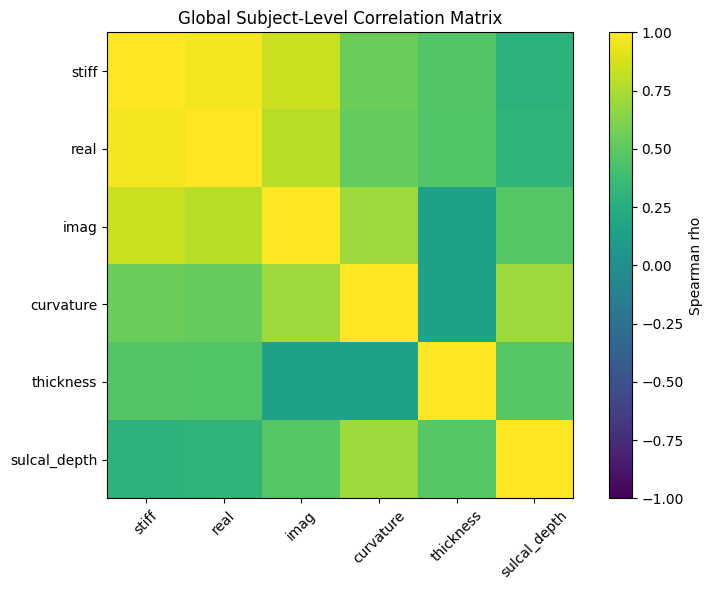

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Parameters to include
parameters = [
    "stiff",
    "real",
    "imag",
    "curvature",
    "thickness",
    "sulcal_depth",
    "myelin",
]

# Store subject-level global means
subject_means = {param: [] for param in parameters}

for sub in subids:
    for param in parameters:

        # average across both hemispheres
        lh_mean = subject_data_on_fsaverage[sub][param]["lh"].mean()
        rh_mean = subject_data_on_fsaverage[sub][param]["rh"].mean()

        subject_means[param].append((lh_mean + rh_mean) / 2)

# Convert to DataFrame
df = pd.DataFrame(subject_means, index=subids)

print("\nSubject-level means:")
print(df)

# Compute Spearman correlation matrix
corr_matrix = df.corr(method="spearman")

print("\nSpearman correlation matrix:")
print(corr_matrix)

# Plot correlation matrix
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Spearman rho")
plt.xticks(range(len(parameters)), parameters, rotation=45)
plt.yticks(range(len(parameters)), parameters)
plt.title("Global Subject-Level Correlation Matrix")
plt.tight_layout()
plt.show()